# Turning Controller

**Authors:** Victor Alfred Stimpfling, Sibo Wang-Chen, Thomas Ka Chung Lam

**Summary:** In this tutorial, we demonstrate how to implement turning by asymmetrically modulating the amplitude and frequency of CPGs on each side of the body.

## Approach

We use a 2-dimensional descending signal $[\delta_L, \delta_R] \in \mathbb{R}^2$ to modulate the CPGs on each side of the body. Specifically, the intrinsic amplitude $R'$ and intrinsic frequency $\nu'$ on each side are modulated as follows:

$$
R'(\delta) = |\delta|
$$

$$
\nu_i'(\delta) = \begin{cases}
\nu_i   & \text{if } \delta > 0 \\
-\nu_i  & \text{otherwise}
\end{cases}
$$

The magnitude of the descending signal controls the step amplitude (as a gain applied to the originally recorded step size), and the sign controls the stepping direction. This is a simplified model of turning: notably, it assumes the step size scales linearly from 0 to 1× the recorded step size.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from flygym.examples.locomotion import PreprogrammedSteps, CPGNetwork
from utils import LEG_NAMES, run_simulation, show_video

In [2]:
_tripod_phase_biases = np.pi * np.array(
    [
        [0, 1, 0, 1, 0, 1],
        [1, 0, 1, 0, 1, 0],
        [0, 1, 0, 1, 0, 1],
        [1, 0, 1, 0, 1, 0],
        [0, 1, 0, 1, 0, 1],
        [1, 0, 1, 0, 1, 0],
    ]
)
_tripod_coupling_weights = (_tripod_phase_biases > 0) * 10


class TurningController:
    """Controller that uses a CPG network to generate turning behavior.

    The controller receives a 2D descending signal to modulate the
    amplitudes and frequencies of the CPGs, producing asymmetric stepping
    for turning.

    Parameters
    ----------
    timestep : float
        Simulation timestep in seconds.
    intrinsic_freqs : np.ndarray, optional
        Intrinsic frequencies of the CPGs (Hz). Shape (6,).
    intrinsic_amps : np.ndarray, optional
        Intrinsic amplitudes of the CPGs. Shape (6,).
    phase_biases : np.ndarray, optional
        Phase biases between CPGs. Shape (6, 6).
    coupling_weights : np.ndarray, optional
        Coupling weights between CPGs. Shape (6, 6).
    convergence_coefs : np.ndarray, optional
        Rate of convergence to intrinsic amplitudes. Shape (6,).
    init_phases : np.ndarray, optional
        Initial phases. Shape (6,).
    init_magnitudes : np.ndarray, optional
        Initial magnitudes. Shape (6,).
    seed : int, optional
        Random seed for CPG network initialization.
    """

    def __init__(
        self,
        timestep,
        intrinsic_freqs=np.ones(6) * 12,
        intrinsic_amps=np.ones(6) * 1,
        phase_biases=_tripod_phase_biases,
        coupling_weights=_tripod_coupling_weights,
        convergence_coefs=np.ones(6) * 20,
        init_phases=None,
        init_magnitudes=None,
        seed=0,
    ):
        self.preprogrammed_steps = PreprogrammedSteps()
        self.intrinsic_freqs = intrinsic_freqs
        self.cpg_network = CPGNetwork(
            timestep=timestep,
            intrinsic_freqs=intrinsic_freqs,
            intrinsic_amps=intrinsic_amps,
            coupling_weights=coupling_weights,
            phase_biases=phase_biases,
            convergence_coefs=convergence_coefs,
            init_phases=init_phases,
            init_magnitudes=init_magnitudes,
            seed=seed,
        )

    def reset(self, init_phases=None, init_magnitudes=None):
        self.cpg_network.reset(init_phases=init_phases, init_magnitudes=init_magnitudes)

    def step(self, action):
        """Step the controller forward one timestep.

        Parameters
        ----------
        action : np.ndarray
            Array of shape (2,) containing the descending signal
            [delta_L, delta_R] for turning.

        Returns
        -------
        joint_angles : np.ndarray
            Flattened array of joint angles, shape (42,).
        adhesion : np.ndarray
            Adhesion on/off signal per leg, shape (6,).
        """
        # Update CPG parameters based on descending signal
        amps = np.repeat(np.abs(action[:, np.newaxis]), 3, axis=1).ravel()
        freqs = self.intrinsic_freqs.copy()
        freqs[:3] *= 1 if action[0] > 0 else -1
        freqs[3:] *= 1 if action[1] > 0 else -1
        self.cpg_network.intrinsic_amps = amps
        self.cpg_network.intrinsic_freqs = freqs

        self.cpg_network.step()

        joint_angles = np.zeros((6, 7))
        adhesion = np.zeros(6)
        for i, leg in enumerate(self.preprogrammed_steps.legs):
            joint_angles[i] = self.preprogrammed_steps.get_joint_angles(
                leg,
                self.cpg_network.curr_phases[i],
                self.cpg_network.curr_magnitudes[i],
            )
            adhesion[i] = self.preprogrammed_steps.get_adhesion_onoff(
                leg, self.cpg_network.curr_phases[i]
            )

        return joint_angles.ravel(), adhesion

## Running a turning simulation

Let's run a simulation applying a constant descending signal of $[\delta_L, \delta_R] = [1.2, 0.2]$ — the left legs take larger steps than the right, causing the fly to turn to the right. We also record the CPG magnitudes over time.

In [3]:
timestep = 1e-4
run_time = 1.0
num_steps = int(run_time / timestep)
action = np.array([1.2, 0.2])

controller = TurningController(timestep=timestep)
joint_angles = np.zeros((num_steps, 42))
adhesion = np.zeros((num_steps, 6))
magnitudes = np.zeros((num_steps, 6))
for i in range(num_steps):
    joint_angles[i], adhesion[i] = controller.step(action)
    magnitudes[i] = controller.cpg_network.curr_magnitudes

In [4]:
sim, _ = run_simulation(
    dof_angles=joint_angles,
    adhesion_segments=[f"{leg}_tarsus5" for leg in LEG_NAMES],
    adhesion_signals=adhesion,
)
show_video(sim)

100%|██████████| 10000/10000 [00:02<00:00, 3724.80it/s]


nmf/trackcam This browser does not support the video tag.


Let's visualise the CPG magnitudes over time. As expected, the left-side CPGs converge to a larger amplitude while the right-side CPGs converge to a smaller one.

Text(0, 0.5, 'CPG magnitude')

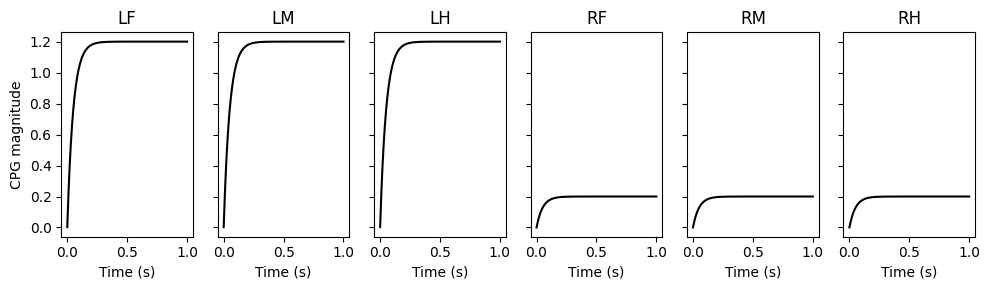

In [5]:
t = np.arange(num_steps) * timestep
fig, axs = plt.subplots(
    1, 6, figsize=(10, 3), tight_layout=True, sharex=True, sharey=True
)
for i, mag in enumerate(magnitudes.T):
    axs[i].plot(t, mag, color="k")
    axs[i].set_xlabel("Time (s)")
    axs[i].set_title(LEG_NAMES[i].upper())
axs[0].set_ylabel("CPG magnitude")